In [1]:
import pandas as pd
import requests
import zipfile

pd.options.display.float_format = '{:.4f}'.format

In [2]:
ano = "2025"
mes = "12"

url = f'https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_{ano}{mes}.zip'

url

'https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202512.zip'

In [3]:
download = requests.get(url)

print("Status:", download.status_code)

with open(f"inf_diario_fi_{ano}{mes}.zip", "wb") as arquivo_cvm:
    arquivo_cvm.write(download.content)

arquivo_zip = zipfile.ZipFile(f"inf_diario_fi_{ano}{mes}.zip")

arquivo_zip.namelist()

Status: 200


['inf_diario_fi_202512.csv']

In [4]:
dados_fundos = pd.read_csv(
    arquivo_zip.open(arquivo_zip.namelist()[0]),
    sep=";",
    encoding="ISO-8859-1"
)

dados_fundos.head()

,TP_FUNDO_CLASSE,CNPJ_FUNDO_CLASSE,ID_SUBCLASSE,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
0,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-01,1054330.6700,41.2509,1190225.1000,0.0000,0.0000,1
1,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-02,1054906.9700,41.2689,1190746.0900,0.0000,0.0000,1
2,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-03,1055478.5000,41.2870,1191268.4000,0.0000,0.0000,1
3,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-04,1056048.4700,41.3050,1191785.9400,0.0000,0.0000,1
4,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-05,1056623.7400,41.3213,1192258.0600,0.0000,0.0000,1


In [5]:
dados_cadastro = pd.read_csv(
    'https://dados.cvm.gov.br/dados/FI/CAD/DADOS/cad_fi.csv',
    sep=";",
    encoding="ISO-8859-1"
)

dados_cadastro = dados_cadastro[
    ['CNPJ_FUNDO', 'DENOM_SOCIAL']
]

dados_cadastro = dados_cadastro.drop_duplicates()

dados_cadastro.head()

/tmp/ipykernel_33247/1203429465.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  dados_cadastro = pd.read_csv(


,CNPJ_FUNDO,DENOM_SOCIAL
0,00.000.684/0001-21,DEUTSCHE BANK FDO APLIC QUOTAS FDO INV FINANCE...
1,00.000.731/0001-37,ITAMARITI CASH FUNDO APLICACAO QUOTAS FDOS INV...
2,00.000.732/0001-81,FUNDO APLIC. QUOTAS DE F.I. SANTANDER CURTO PRAZO
3,00.000.740/0001-28,FUNDO DE APLIC EM QUOTAS DE FUNDOS DE INV BMC ...
4,00.000.749/0001-39,BALANCE FUNDO APLICACAO QUOTAS FUNDO INVESTIME...


In [6]:
data_inicio_mes = dados_fundos['DT_COMPTC'].min()

data_fim_mes = dados_fundos['DT_COMPTC'].max()

print("Início:", data_inicio_mes)
print("Fim:", data_fim_mes)

Início: 2025-12-01
Fim: 2025-12-31


In [7]:
dados_fundos_filtrado = dados_fundos[
    dados_fundos['DT_COMPTC'].isin(
        [data_inicio_mes, data_fim_mes]
    )
]

dados_fundos_filtrado.head()

,TP_FUNDO_CLASSE,CNPJ_FUNDO_CLASSE,ID_SUBCLASSE,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
0,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-01,1054330.6700,41.2509,1190225.1000,0.0000,0.0000,1
21,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-31,1066622.4900,41.6116,1197546.3300,0.0000,0.0000,1
22,CLASSES - FIF,00.068.305/0001-35,NaN,2025-12-01,39725204.1900,43.3052,39370431.6600,0.0000,516.3600,5659
43,CLASSES - FIF,00.068.305/0001-35,NaN,2025-12-31,39596670.4800,43.7544,39587262.6200,0.0000,0.0000,5644
44,CLASSES - FIF,00.071.477/0001-68,NaN,2025-12-01,873828816.2900,15.2865,873755812.3800,233244.2000,1870415.7800,31415


In [8]:
# Encontrar automaticamente as colunas de CNPJ

coluna_cnpj_fundos = [
    col for col in dados_fundos_filtrado.columns
    if 'CNPJ' in col.upper()
][0]

coluna_cnpj_cadastro = [
    col for col in dados_cadastro.columns
    if 'CNPJ' in col.upper()
][0]

base_final = pd.merge(
    dados_fundos_filtrado,
    dados_cadastro,
    how='left',
    left_on=coluna_cnpj_fundos,
    right_on=coluna_cnpj_cadastro
)

base_final.head()

,TP_FUNDO_CLASSE,CNPJ_FUNDO_CLASSE,ID_SUBCLASSE,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST,CNPJ_FUNDO,DENOM_SOCIAL
0,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-01,1054330.6700,41.2509,1190225.1000,0.0000,0.0000,1,00.017.024/0001-53,FIF - CLASSE DE INVESTIMENTO RENDA FIXA EXPO...
1,CLASSES - FIF,00.017.024/0001-53,NaN,2025-12-31,1066622.4900,41.6116,1197546.3300,0.0000,0.0000,1,00.017.024/0001-53,FIF - CLASSE DE INVESTIMENTO RENDA FIXA EXPO...
2,CLASSES - FIF,00.068.305/0001-35,NaN,2025-12-01,39725204.1900,43.3052,39370431.6600,0.0000,516.3600,5659,00.068.305/0001-35,CAIXA EMPREENDER FIC DE CLASSE DE FIF RENDA FI...
3,CLASSES - FIF,00.068.305/0001-35,NaN,2025-12-31,39596670.4800,43.7544,39587262.6200,0.0000,0.0000,5644,00.068.305/0001-35,CAIXA EMPREENDER FIC DE CLASSE DE FIF RENDA FI...
4,CLASSES - FIF,00.071.477/0001-68,NaN,2025-12-01,873828816.2900,15.2865,873755812.3800,233244.2000,1870415.7800,31415,00.071.477/0001-68,BB RENDA FIXA AUTOMÁTICO EMPRESA SIMPLES FIC D...


In [9]:
print("Quantidade de registros:", len(base_final))
print("Quantidade de fundos:", base_final[coluna_cnpj_fundos].nunique())

base_final[
    [
        'DENOM_SOCIAL',
        'VL_PATRIM_LIQ',
        'NR_COTST'
    ]
].head()

Quantidade de registros: 50537
Quantidade de fundos: 25452


,DENOM_SOCIAL,VL_PATRIM_LIQ,NR_COTST
0,FIF - CLASSE DE INVESTIMENTO RENDA FIXA EXPO...,1190225.1000,1
1,FIF - CLASSE DE INVESTIMENTO RENDA FIXA EXPO...,1197546.3300,1
2,CAIXA EMPREENDER FIC DE CLASSE DE FIF RENDA FI...,39370431.6600,5659
3,CAIXA EMPREENDER FIC DE CLASSE DE FIF RENDA FI...,39587262.6200,5644
4,BB RENDA FIXA AUTOMÁTICO EMPRESA SIMPLES FIC D...,873755812.3800,31415


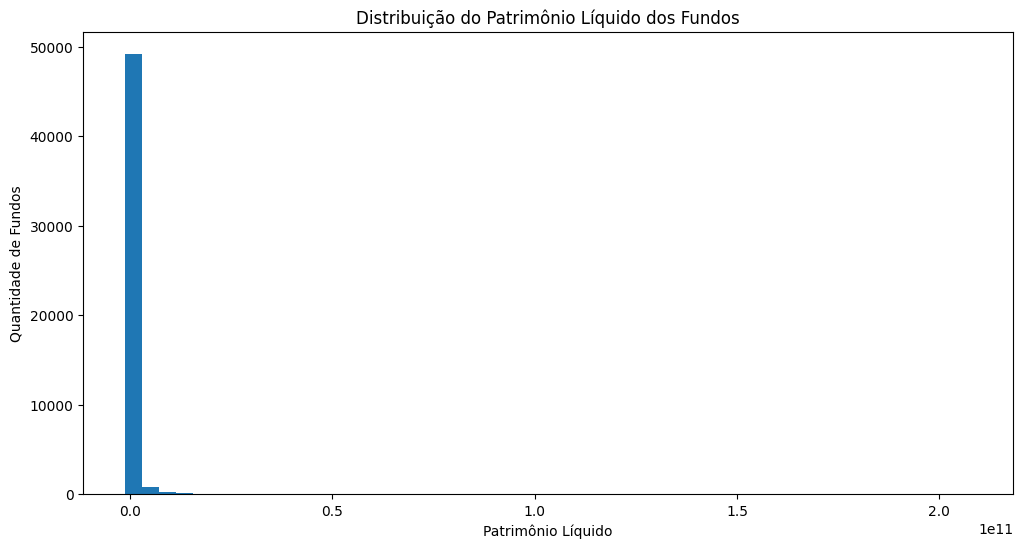

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.hist(
    base_final['VL_PATRIM_LIQ'],
    bins=50
)

plt.title(
    'Distribuição do Patrimônio Líquido dos Fundos'
)

plt.xlabel(
    'Patrimônio Líquido'
)

plt.ylabel(
    'Quantidade de Fundos'
)

plt.show()

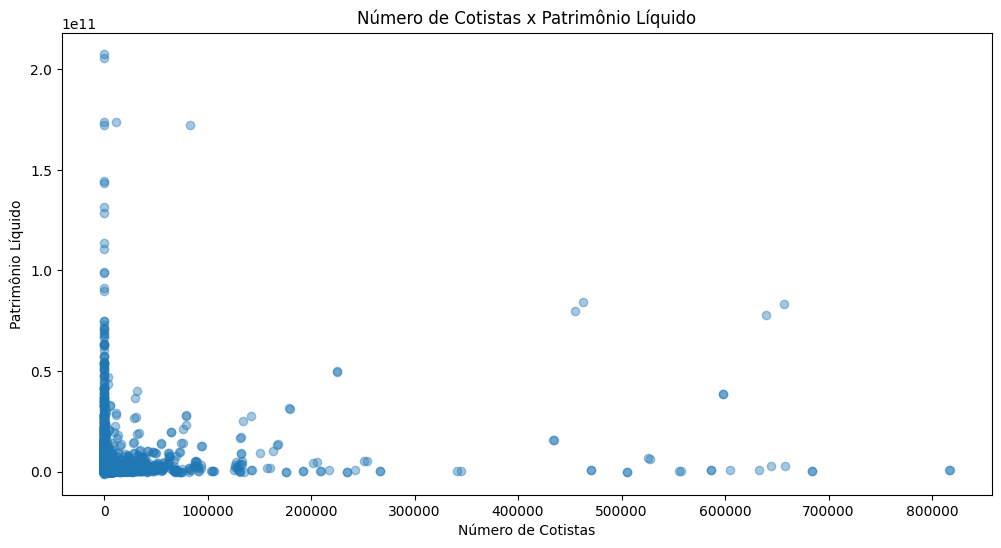

In [11]:
plt.figure(figsize=(12,6))

plt.scatter(
    base_final['NR_COTST'],
    base_final['VL_PATRIM_LIQ'],
    alpha=0.4
)

plt.title(
    'Número de Cotistas x Patrimônio Líquido'
)

plt.xlabel(
    'Número de Cotistas'
)

plt.ylabel(
    'Patrimônio Líquido'
)

plt.show()

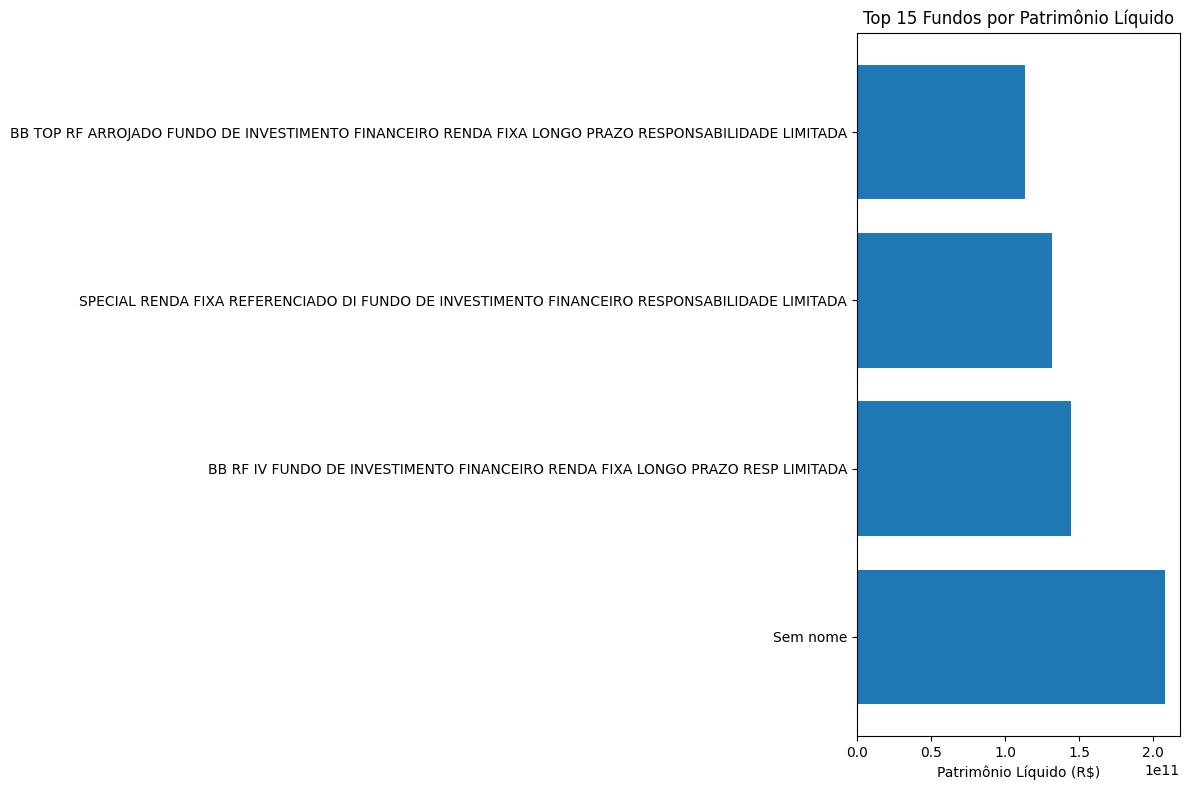

In [12]:
top15 = (
    base_final
    .sort_values(
        'VL_PATRIM_LIQ',
        ascending=False
    )
    .head(15)
    .copy()
)

# Converter para texto e tratar valores nulos
top15['DENOM_SOCIAL'] = (
    top15['DENOM_SOCIAL']
    .fillna('Sem nome')
    .astype(str)
)

plt.figure(figsize=(12,8))

plt.barh(
    top15['DENOM_SOCIAL'],
    top15['VL_PATRIM_LIQ']
)

plt.title(
    'Top 15 Fundos por Patrimônio Líquido'
)

plt.xlabel(
    'Patrimônio Líquido (R$)'
)

plt.tight_layout()

plt.show()

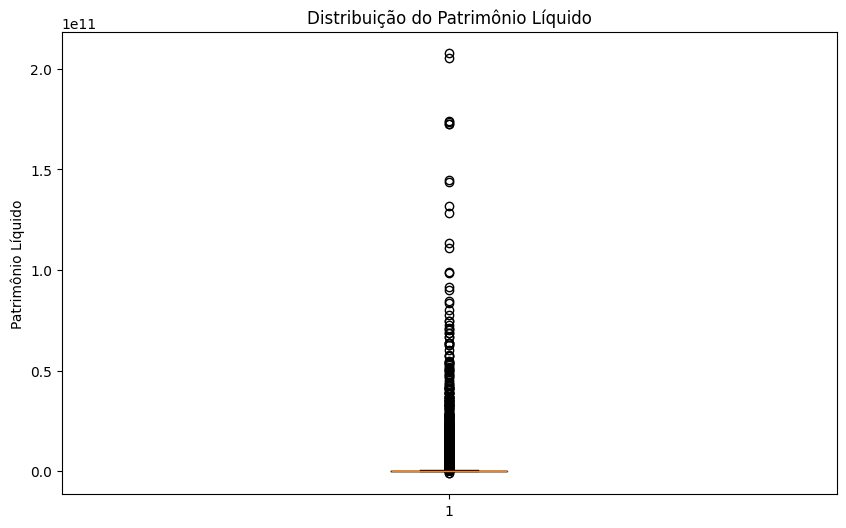

In [13]:
plt.figure(figsize=(10,6))

plt.boxplot(
    base_final['VL_PATRIM_LIQ']
)

plt.title(
    'Distribuição do Patrimônio Líquido'
)

plt.ylabel(
    'Patrimônio Líquido'
)

plt.show()